# Logistic Regression – Wine Dataset


The Wine dataset contains 3 cultivar classes. Predicts the cultivar class using all 13 features.


## 1. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine

# Find the repo root that contains the current package
cwd = Path.cwd()
repo_root = None

# Search current folder and all parent folders
for folder in [cwd] + list(cwd.parents):
    if (folder / "ml_package").exists():
        repo_root = folder
        break

if repo_root is None:
    raise FileNotFoundError(
        "Could not find a folder named 'ml_package'. "
    )

# Add repo root to Python path
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Current working directory:", cwd)
print("Repo root found:", repo_root)
print("Package folder found:", repo_root / "ml_package")


from ml_package.processing.preprocessing import train_test_split, standardize
from ml_package.supervised.logistic_regression import LogisticRegression

Current working directory: /Users/shrutipatankar/CMOR438-Spring2026/notebooks/supervised_learning/logistic_regression
Repo root found: /Users/shrutipatankar/CMOR438-Spring2026
Package folder found: /Users/shrutipatankar/CMOR438-Spring2026/ml_package


## 2. Load the Wine Dataset

We use `sklearn.datasets.load_wine()` only to access the dataset.
The model itself will come from your custom package.

The dataset contains:

- 178 wine samples
- 13 numeric chemistry features
- 3 wine cultivar classes (0, 1, 2)

In [2]:
wine = load_wine(as_frame=True)

wine_features = wine.data.copy()
wine_target = wine.target.copy()
class_names = np.array(wine.target_names)

X = wine_features.to_numpy()
y = wine_target.to_numpy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", class_names)
print("Class counts:", dict(zip(*np.unique(y, return_counts=True))))

wine_features.head()

Feature matrix shape: (178, 13)
Target shape: (178,)
Classes: ['class_0' 'class_1' 'class_2']
Class counts: {np.int64(0): np.int64(59), np.int64(1): np.int64(71), np.int64(2): np.int64(48)}


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 3. Exploratory Data Analysis

In [3]:
wine_features.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


/var/folders/37/cm4mfffd2_b6bq6_rzdkw6qm0000gn/T/ipykernel_25740/1465116835.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wine_features.columns, rotation=90, fontsize=7)
/var/folders/37/cm4mfffd2_b6bq6_rzdkw6qm0000gn/T/ipykernel_25740/1465116835.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wine_features.columns, rotation=90, fontsize=7)
/var/folders/37/cm4mfffd2_b6bq6_rzdkw6qm0000gn/T/ipykernel_25740/1465116835.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wine_features.columns, rotation=90, fontsize=7)


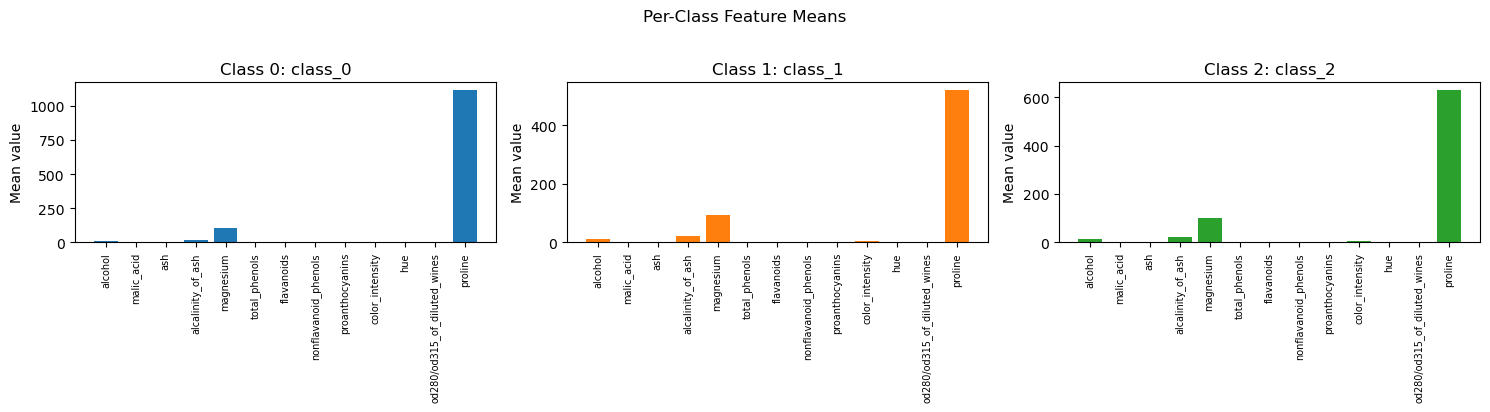

In [4]:
# Per-class feature means — helps identify which features separate classes
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for class_id, ax in enumerate(axes):
    mask = y == class_id
    ax.bar(wine_features.columns, wine_features[mask].mean(), color=f"C{class_id}")
    ax.set_title(f"Class {class_id}: {class_names[class_id]}")
    ax.set_xticklabels(wine_features.columns, rotation=90, fontsize=7)
    ax.set_ylabel("Mean value")

plt.suptitle("Per-Class Feature Means", y=1.02)
plt.tight_layout()
plt.show()

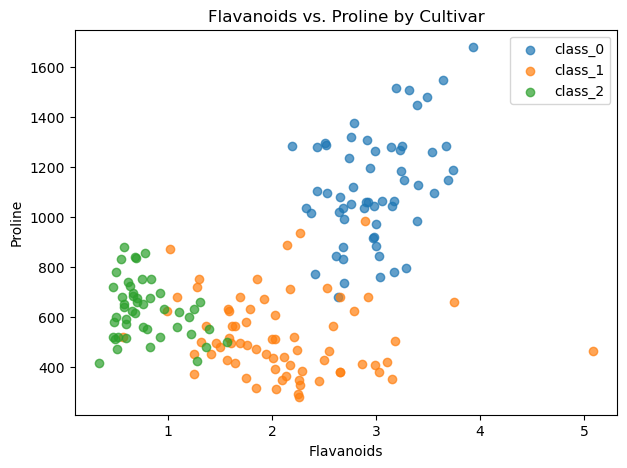

In [5]:
# Scatter plot of the two most discriminating features
fig, ax = plt.subplots(figsize=(7, 5))

for class_id in range(3):
    mask = y == class_id
    ax.scatter(
        wine_features.loc[mask, "flavanoids"],
        wine_features.loc[mask, "proline"],
        label=class_names[class_id],
        alpha=0.7,
        color=f"C{class_id}",
    )

ax.set_xlabel("Flavanoids")
ax.set_ylabel("Proline")
ax.set_title("Flavanoids vs. Proline by Cultivar")
ax.legend()
plt.show()

## 4. Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)

X_train: (142, 13) | X_test: (36, 13)
y_train: (142,) | y_test: (36,)


## 5. Standardize Features

Logistic regression is scale-sensitive. We standardize the training set and apply the same parameters to the test set to avoid data leakage.

In [7]:
X_train_scaled, scaling_params = standardize(X_train, return_params=True)
X_test_scaled = standardize(
    X_test,
    mean=scaling_params["mean"],
    scale=scaling_params["scale"],
)

print("Training feature means after scaling:")
print(np.round(X_train_scaled.mean(axis=0), 6))

print("\nTraining feature standard deviations after scaling:")
print(np.round(X_train_scaled.std(axis=0), 6))

Training feature means after scaling:
[ 0. -0. -0.  0.  0.  0.  0. -0.  0. -0.  0.  0. -0.]

Training feature standard deviations after scaling:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 6. Evaluation Helper Functions

In [8]:
def accuracy(y_true, y_pred):
    return float(np.mean(np.asarray(y_true) == np.asarray(y_pred)))


def confusion_matrix(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


def plot_confusion_matrix(cm, class_names, title="Confusion Matrix"):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax)
    ax.set(
        xticks=range(len(class_names)), yticks=range(len(class_names)),
        xticklabels=class_names, yticklabels=class_names,
        xlabel="Predicted", ylabel="Actual", title=title,
    )
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.tight_layout()
    plt.show()


def evaluate(model, X_train, y_train, X_test, y_test):
    return {
        "Train Accuracy": accuracy(y_train, model.predict(X_train)),
        "Test Accuracy":  accuracy(y_test,  model.predict(X_test)),
        "Iterations":     model.n_iter_,
    }

## 7. Multinomial Softmax Regression

Trains a single model with a softmax output layer. This is the `multi_class='multinomial'` mode.

The model minimizes:

$$\mathcal{L} = -\frac{1}{n}\sum_{i=1}^{n}\sum_{k=1}^{K} y_{ik} \log \hat{p}_{ik}$$

In [9]:
softmax_model = LogisticRegression(
    learning_rate=0.1,
    max_iter=1000,
    multi_class="multinomial",
    standardize=False,  # already standardized using preprocessing.standardize()
    random_state=42,
)

softmax_model.fit(X_train_scaled, y_train)

softmax_results = evaluate(softmax_model, X_train_scaled, y_train, X_test_scaled, y_test)
pd.DataFrame([softmax_results], index=["Multinomial"])

,Train Accuracy,Test Accuracy,Iterations
Multinomial,1.0,1.0,1000


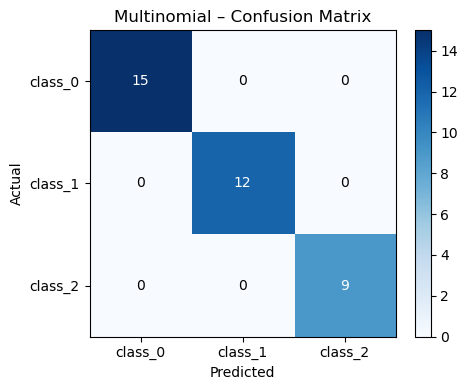

In [10]:
cm = confusion_matrix(y_test, softmax_model.predict(X_test_scaled), n_classes=3)
plot_confusion_matrix(cm, class_names, title="Multinomial – Confusion Matrix")

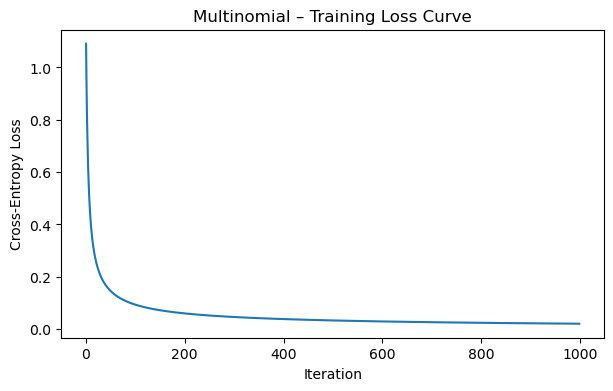

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(softmax_model.loss_history_)
plt.xlabel("Iteration")
plt.ylabel("Cross-Entropy Loss")
plt.title("Multinomial – Training Loss Curve")
plt.show()

## 8. One-vs-Rest Regression

Trains one binary sigmoid classifier per class. The class with the highest score wins.

This is the `multi_class='ovr'` mode.

In [12]:
ovr_model = LogisticRegression(
    learning_rate=0.1,
    max_iter=1000,
    multi_class="ovr",
    standardize=False,
    random_state=42,
)

ovr_model.fit(X_train_scaled, y_train)

ovr_results = evaluate(ovr_model, X_train_scaled, y_train, X_test_scaled, y_test)
pd.DataFrame([ovr_results], index=["OvR"])

,Train Accuracy,Test Accuracy,Iterations
OvR,0.992958,1.0,1000


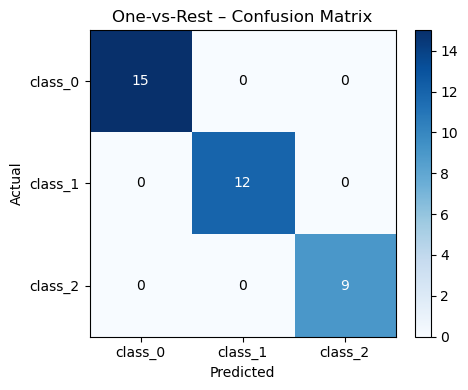

In [13]:
cm_ovr = confusion_matrix(y_test, ovr_model.predict(X_test_scaled), n_classes=3)
plot_confusion_matrix(cm_ovr, class_names, title="One-vs-Rest – Confusion Matrix")

## 9. Effect of L2 Regularization

The `l2_penalty` parameter adds an L2 penalty to the loss:

$$\mathcal{L}_{\text{reg}} = \mathcal{L} + \frac{\lambda}{2} \sum_{j} \beta_j^2$$

Higher penalty shrinks coefficients and can reduce overfitting. The intercept is never penalized.

In [14]:
penalties = [0.0, 0.01, 0.1, 1.0, 10.0]
reg_rows = []

for lam in penalties:
    model = LogisticRegression(
        learning_rate=0.1,
        max_iter=1000,
        multi_class="multinomial",
        standardize=False,
        l2_penalty=lam,
        random_state=42,
    )
    model.fit(X_train_scaled, y_train)
    reg_rows.append({
        "l2_penalty": lam,
        "Train Accuracy": accuracy(y_train, model.predict(X_train_scaled)),
        "Test Accuracy":  accuracy(y_test,  model.predict(X_test_scaled)),
        "Iterations": model.n_iter_,
    })

reg_df = pd.DataFrame(reg_rows)
reg_df

,l2_penalty,Train Accuracy,Test Accuracy,Iterations
0,0.00,1.000000,1.000000,1000
1,0.01,1.000000,1.000000,1000
2,0.10,0.992958,1.000000,411
3,1.00,0.985915,0.944444,149
4,10.00,0.542254,0.388889,105


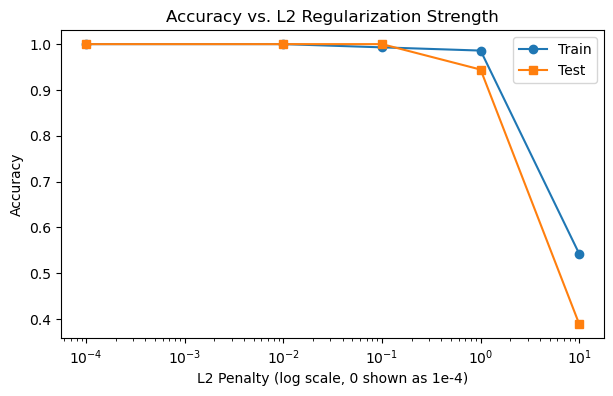

In [15]:
plt.figure(figsize=(7, 4))
x_vals = [1e-4 if v == 0 else v for v in reg_df["l2_penalty"]]
plt.semilogx(x_vals, reg_df["Train Accuracy"], marker="o", label="Train")
plt.semilogx(x_vals, reg_df["Test Accuracy"],  marker="s", label="Test")
plt.xlabel("L2 Penalty (log scale, 0 shown as 1e-4)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. L2 Regularization Strength")
plt.legend()
plt.show()

## 10. Compare All Strategies

In [16]:
models = {
    "Multinomial":          LogisticRegression(learning_rate=0.1, max_iter=1000, multi_class="multinomial", standardize=False, random_state=42),
    "OvR":                  LogisticRegression(learning_rate=0.1, max_iter=1000, multi_class="ovr",         standardize=False, random_state=42),
    "Multinomial + L2=0.1": LogisticRegression(learning_rate=0.1, max_iter=1000, multi_class="multinomial", standardize=False, l2_penalty=0.1, random_state=42),
    "OvR + L2=0.1":         LogisticRegression(learning_rate=0.1, max_iter=1000, multi_class="ovr",         standardize=False, l2_penalty=0.1, random_state=42),
}

comparison_rows = []
fitted = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    comparison_rows.append({"Model": name, **evaluate(model, X_train_scaled, y_train, X_test_scaled, y_test)})
    fitted[name] = model

comparison_df = pd.DataFrame(comparison_rows).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
comparison_df

,Model,Train Accuracy,Test Accuracy,Iterations
0,Multinomial,1.000000,1.0,1000
1,OvR,0.992958,1.0,1000
2,Multinomial + L2=0.1,0.992958,1.0,411
3,OvR + L2=0.1,0.992958,1.0,931


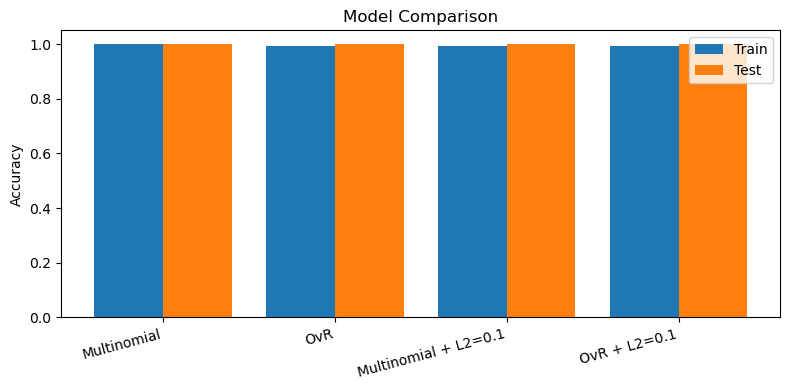

In [17]:
x = range(len(comparison_df))
plt.figure(figsize=(8, 4))
plt.bar([i - 0.2 for i in x], comparison_df["Train Accuracy"], width=0.4, label="Train")
plt.bar([i + 0.2 for i in x], comparison_df["Test Accuracy"],  width=0.4, label="Test")
plt.xticks(list(x), comparison_df["Model"], rotation=15, ha="right")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Interpret Coefficients

Because the predictors were standardized, each coefficient can be interpreted as:

> the expected change in log-odds for a one-standard-deviation increase in that feature, holding all others fixed.

We use the best model from the comparison above.

In [18]:
best_name = comparison_df.iloc[0]["Model"]
best_model = fitted[best_name]
print("Best model:", best_name)

coef_df = pd.DataFrame(
    best_model.coef_,
    index=[f"Class {i}: {class_names[i]}" for i in range(3)],
    columns=wine_features.columns,
)
coef_df

Best model: Multinomial


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
Class 0: class_0,1.013175,0.336155,0.505698,-1.042671,0.063945,0.393586,0.684836,-0.295347,0.129339,0.314811,-0.005421,0.779562,1.258701
Class 1: class_1,-1.209034,-0.528176,-0.986602,0.727638,-0.091388,-0.037435,0.413392,0.217757,0.176242,-1.442539,0.805113,-0.078639,-1.429321
Class 2: class_2,0.172733,0.189969,0.488945,0.331641,0.012949,-0.349715,-1.094356,0.075108,-0.293491,1.139958,-0.790380,-0.718709,0.189990


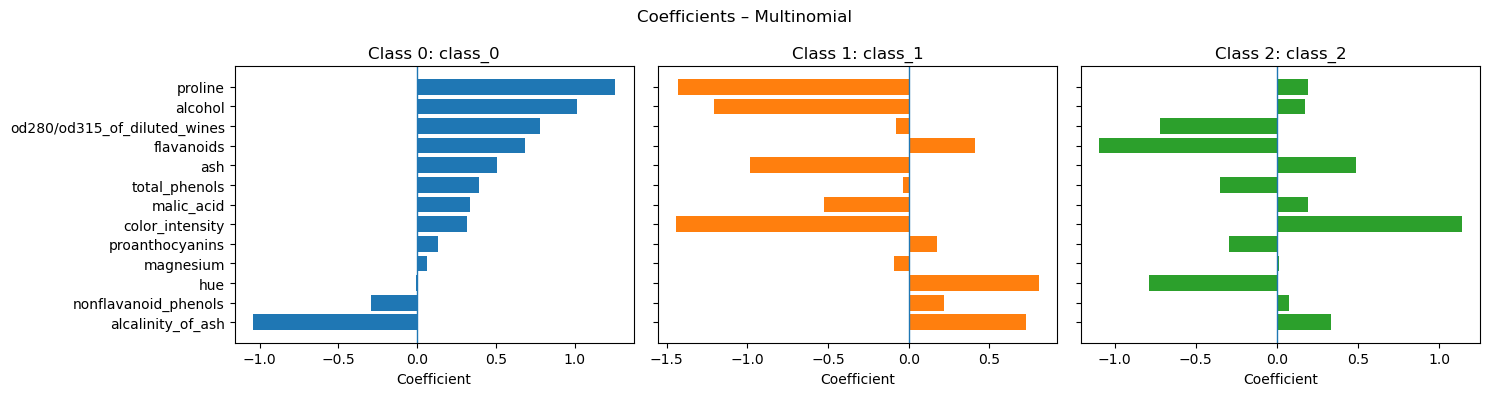

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for class_id, ax in enumerate(axes):
    coefs = best_model.coef_[class_id]
    sorted_idx = np.argsort(coefs)
    ax.barh(wine_features.columns[sorted_idx], coefs[sorted_idx], color=f"C{class_id}")
    ax.axvline(0, linewidth=1)
    ax.set_title(f"Class {class_id}: {class_names[class_id]}")
    ax.set_xlabel("Coefficient")

plt.suptitle(f"Coefficients – {best_name}")
plt.tight_layout()
plt.show()

## 12. Predicted Probabilities

Each row in `predict_proba()` sums to 1. The predicted class is the one with the highest probability.

In [20]:
proba = best_model.predict_proba(X_test_scaled)
proba_df = pd.DataFrame(proba, columns=[f"P(class {i})" for i in range(3)])
proba_df["Predicted"] = best_model.predict(X_test_scaled)
proba_df["Actual"]    = y_test
proba_df["Correct"]   = proba_df["Predicted"] == proba_df["Actual"]
proba_df.head(10)

,P(class 0),P(class 1),P(class 2),Predicted,Actual,Correct
0,0.000225,0.003826,0.995949,2,2,True
1,0.007058,0.992448,0.000494,1,1,True
2,0.999688,0.000021,0.000291,0,0,True
3,0.000448,0.014017,0.985535,2,2,True
4,0.998974,0.000955,0.000071,0,0,True
5,0.934562,0.064261,0.001177,0,0,True
6,0.005970,0.253659,0.740371,2,2,True
7,0.000026,0.999846,0.000128,1,1,True
8,0.997403,0.000964,0.001633,0,0,True
9,0.001707,0.064443,0.933850,2,2,True


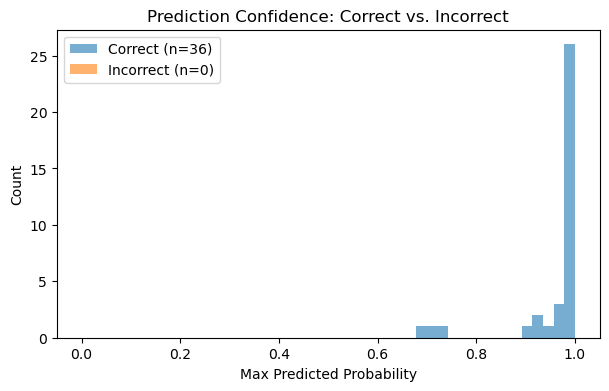

In [21]:
correct_conf   = proba[proba_df["Correct"]].max(axis=1)
incorrect_conf = proba[~proba_df["Correct"]].max(axis=1)

plt.figure(figsize=(7, 4))
plt.hist(correct_conf,   bins=15, alpha=0.6, label=f"Correct (n={len(correct_conf)})")
plt.hist(incorrect_conf, bins=15, alpha=0.6, label=f"Incorrect (n={len(incorrect_conf)})")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Count")
plt.title("Prediction Confidence: Correct vs. Incorrect")
plt.legend()
plt.show()

## 13. Prediction Example on One Wine

In [22]:
example_index = 0
x_example  = X_test_scaled[example_index].reshape(1, -1)
true_label  = y_test[example_index]
pred_label  = best_model.predict(x_example)[0]
pred_proba  = best_model.predict_proba(x_example)[0]

print(f"True class:      {true_label} ({class_names[true_label]})")
print(f"Predicted class: {pred_label} ({class_names[pred_label]})")
print(f"Correct:         {true_label == pred_label}")
print()
for i, p in enumerate(pred_proba):
    print(f"  P(class {i} – {class_names[i]}): {p:.4f}")

True class:      2 (class_2)
Predicted class: 2 (class_2)
Correct:         True

  P(class 0 – class_0): 0.0002
  P(class 1 – class_1): 0.0038
  P(class 2 – class_2): 0.9959
